In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [2]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

# globales
total = df_fe
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]
mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]
mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]
marmol_quinto = marmol[marmol['grado']=="Quinto"]
marmol_sexto = marmol[marmol['grado']=="Sexto"]

cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
cant_mantovani_cuarto = len(mantovani_cuarto)
cant_mantovani_quinto = len(mantovani_quinto)
cant_mantovani_sexto = len(mantovani_sexto)
cant_marmol_quinto = len(marmol_quinto)
cant_marmol_sexto = len(marmol_sexto)

fig_name_prefix = 'cant_misc_por_chique'
file_ext = '.png'
dpi_value = 200
include_title = True

Shape of data:  (369, 22)


In [27]:
# Misc por chique
def analizar_misc_por_preg(df):
    
    ## Almacenamiento videos YouTube

    donde_youtube = df["donde_youtube"]

    column_names = ["En mi celular",
                    "En una computadora",
                    "En la nube",
                    "En muchas computadoras (tantas que podrían llenar una casa)",
                    "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)",
                    "No sé"]

    donde_youtube = pd.get_dummies(donde_youtube)
    donde_youtube = donde_youtube.reindex(columns=column_names, fill_value=0)
    donde_youtube = donde_youtube.sum()

    misc_donde_youtube =  donde_youtube.get("En mi celular") + \
                    donde_youtube.get("En una computadora") + \
                    donde_youtube.get("En la nube") + \
                    donde_youtube.get("En muchas computadoras (tantas que podrían llenar una casa)")

    nose_donde_youtube = donde_youtube.get("No sé")
    not_misc_donde_youtube = donde_youtube.get("En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)")

    ## Enviar foto WPP

    amiga_wpp = df["amiga_wpp"]

    column_names = ["Le doy permiso para ver la foto que tengo guardada en mi celular.",
                    "Le mando una copia de mi foto.",
                    "La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular",
                    "No sé"]

    amiga_wpp = pd.get_dummies(amiga_wpp)
    amiga_wpp = amiga_wpp.reindex(columns=column_names, fill_value=0)
    amiga_wpp = amiga_wpp.sum()

    misc_amiga_wpp = amiga_wpp.get("Le doy permiso para ver la foto que tengo guardada en mi celular.") +\
                     amiga_wpp.get("La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular")
    nose_amiga_wpp = amiga_wpp.get("No sé")
    not_misc_amiga_wpp = amiga_wpp.get("Le mando una copia de mi foto.")

    ## Dejar de ver foto en WPP

    amiga_no_ver_foto = df["amiga_no_ver_foto"]

    column_names = ["Tengo que borrar la foto en el chat.",
                    "Tengo que borrar la foto en la Galería de fotos de mi celular.",
                    "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.",
                    "No sé"]

    amiga_no_ver_foto = pd.get_dummies(amiga_no_ver_foto)
    amiga_no_ver_foto = amiga_no_ver_foto.reindex(columns=column_names, fill_value=0)
    amiga_no_ver_foto = amiga_no_ver_foto.sum()

    misc_amiga_no_ver_foto = amiga_no_ver_foto.get("Tengo que borrar la foto en el chat.") +\
                             amiga_no_ver_foto.get("Tengo que borrar la foto en la Galería de fotos de mi celular.")
    nose_amiga_no_ver_foto = amiga_no_ver_foto.get("No sé")
    not_misc_amiga_no_ver_foto = amiga_no_ver_foto.get("No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.")

    ## Como viaja mensaje sin Wi-Fi

    como_viaja_wpp = df["como_viaja_wpp"]

    column_names = ["El mensaje se manda directamente.",
                    "El mensaje se manda a través de la nube.",
                    "El mensaje se manda a través de un satélite.",
                    "El mensaje se manda a través de una antena.",
                    "El mensaje se manda a través de una red de antenas y computadoras.",
                    "No sé"]

    como_viaja_wpp = pd.get_dummies(como_viaja_wpp)
    como_viaja_wpp = como_viaja_wpp.reindex(columns=column_names, fill_value=0)
    como_viaja_wpp = como_viaja_wpp.sum()

    misc_como_viaja_wpp = como_viaja_wpp.get("El mensaje se manda directamente.") +\
                          como_viaja_wpp.get("El mensaje se manda a través de la nube.") +\
                          como_viaja_wpp.get("El mensaje se manda a través de un satélite.") +\
                          como_viaja_wpp.get("El mensaje se manda a través de una antena.")
    nose_como_viaja_wpp = como_viaja_wpp.get("No sé")
    not_misc_como_viaja_wpp = como_viaja_wpp.get("El mensaje se manda a través de una red de antenas y computadoras.")

    ## Link descarga App

    link_descarga = df["link_descarga"]

    column_names = ["Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.",
                    "Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.",
                    "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.",
                    "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.",
                    "No sé."]

    link_descarga = pd.get_dummies(link_descarga)
    link_descarga = link_descarga.reindex(columns=column_names, fill_value=0)
    link_descarga = link_descarga.sum()
    
    misc_link_descarga = link_descarga.get("Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.") +\
                         link_descarga.get("Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.") +\
                         link_descarga.get("Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.")
    nose_link_descarga = link_descarga.get("No sé.")
    not_misc_link_descarga = link_descarga.get("Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.")

    ## Que es la Nube

    que_es_nube = df["que_es_nube"]

    column_names = ["Una nube",
                    "Una parte del celular",
                    "Una red de antenas y satélites",
                    "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)",
                    "Una computadora gigante",
                    "No sé"]

    que_es_nube = pd.get_dummies(que_es_nube)
    que_es_nube = que_es_nube.reindex(columns=column_names, fill_value=0)
    que_es_nube = que_es_nube.sum()

    misc_que_es_nube = que_es_nube.get("Una nube") +\
                       que_es_nube.get("Una parte del celular") +\
                       que_es_nube.get("Una red de antenas y satélites") +\
                       que_es_nube.get("Una computadora gigante")
    nose_que_es_nube = que_es_nube.get("No sé")
    not_misc_que_es_nube = que_es_nube.get("Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)")

    ## Afirmaciones Nube

    def analizar_misc(val):
        lista = val.split(",")
        # sum_miscos = 0
        if "PodemosutilizarlanubesinconexiónaInternet" in lista:
            return "misc"
        if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
            return "misc"
        if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
            return "misc"
        if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
            return "misc"
        return "not_misc"

    afirmaciones_nube = df["afirmaciones_nube"].dropna().str.replace(" ", "").apply(analizar_misc).value_counts()
    misc_afirmaciones_nube = afirmaciones_nube.get("misc")
    nose_afirmaciones_nube = 0
    not_misc_afirmaciones_nube = afirmaciones_nube.get("not_misc")

    ## Como se comportan Nube vs Internet

    como_se_comportan = df["como_se_comportan"]

    column_names = ["Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.",
                    "No sé.",
                    "Con Internet podemos hacer más cosas que con la nube.",
                    "Con la nube podemos hacer más cosas que con Internet.",
                    "Internet y la nube no tienen funciones en común.",
                    "Podemos hacer exactamente lo mismo con Internet que con la nube."]

    como_se_comportan = pd.get_dummies(como_se_comportan)
    como_se_comportan = como_se_comportan.reindex(columns=column_names, fill_value=0)
    como_se_comportan = como_se_comportan.sum()

    misc_como_se_comportan = como_se_comportan.get("Podemos hacer exactamente lo mismo con Internet que con la nube.") +\
                             como_se_comportan.get("Internet y la nube no tienen funciones en común.") +\
                             como_se_comportan.get("Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.") +\
                             como_se_comportan.get("Con la nube podemos hacer más cosas que con Internet.")
    nose_como_se_comportan = como_se_comportan.get("No sé.")
    not_misc_como_se_comportan = como_se_comportan.get("Con Internet podemos hacer más cosas que con la nube.")

    ## Sobre Wikipedia

    sobre_wikipedia = df["sobre_wikipedia"]

    column_names = ["Toda la información en el artículo es verdadera porque está verificada.",
                    "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.",
                    "No hay forma de saber si la información del artículo es verdadera o falsa.",
                    "Hace falta investigar más para decidir si la información es verdadera o falsa."]
    
    sobre_wikipedia = pd.get_dummies(sobre_wikipedia)
    sobre_wikipedia = sobre_wikipedia.reindex(columns=column_names, fill_value=0)
    sobre_wikipedia = sobre_wikipedia.sum()
    
    misc_sobre_wikipedia = sobre_wikipedia.get("Toda la información en el artículo es verdadera porque está verificada.") +\
                           sobre_wikipedia.get("Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.") +\
                           sobre_wikipedia.get("No hay forma de saber si la información del artículo es verdadera o falsa.")
    nose_sobre_wikipedia = 0
    not_misc_sobre_wikipedia = sobre_wikipedia.get("Hace falta investigar más para decidir si la información es verdadera o falsa.")

    index_preguntas = ["Almacenamiento Youtube",
                       "Envío foto wpp",
                       "Dejar de ver foto wpp",
                       "Mensaje sin Wi-Fi",
                       "Link descarga App",
                       "Que es la Nube",
                       "Afirmaciones Nube",
                       "Nube vs Internet",
                       "Sobre Wikipedia"
                       ]
    data = {
        "Misc": [misc_donde_youtube,
                 misc_amiga_wpp,
                 misc_amiga_no_ver_foto,
                 misc_como_viaja_wpp,
                 misc_link_descarga,
                 misc_que_es_nube,
                 misc_afirmaciones_nube,
                 misc_como_se_comportan,
                 misc_sobre_wikipedia ],
        "No sé":[nose_donde_youtube,
                 nose_amiga_wpp,
                 nose_amiga_no_ver_foto,
                 nose_como_viaja_wpp,
                 nose_link_descarga,
                 nose_que_es_nube,
                 nose_afirmaciones_nube,
                 nose_como_se_comportan,
                 nose_sobre_wikipedia ],
        "No Misc":[not_misc_donde_youtube,
                 not_misc_amiga_wpp,
                 not_misc_amiga_no_ver_foto,
                 not_misc_como_viaja_wpp,
                 not_misc_link_descarga,
                 not_misc_que_es_nube,
                 not_misc_afirmaciones_nube,
                 not_misc_como_se_comportan,
                 not_misc_sobre_wikipedia ],
    }
    # print(pd.DataFrame(index=index_preguntas, data=data))
    return pd.DataFrame(index=index_preguntas, data=data)

# Misc por chique

                        Misc  No sé  No Misc
Almacenamiento Youtube   251     97       21
Envío foto wpp           216     55       98
Dejar de ver foto wpp    248     30       91
Mensaje sin Wi-Fi        215    101       53
Link descarga App        166     63      140
Que es la Nube           262     84       21
Afirmaciones Nube        185      0      100
Nube vs Internet         184     54       47
Sobre Wikipedia          167      0      140
                        Misc  No sé  No Misc  Total
Almacenamiento Youtube   251     97       21    369
Envío foto wpp           216     55       98    369
Dejar de ver foto wpp    248     30       91    369
Mensaje sin Wi-Fi        215    101       53    369
Link descarga App        166     63      140    369
Que es la Nube           262     84       21    367
Afirmaciones Nube        185      0      100    285
Nube vs Internet         184     54       47    285
Sobre Wikipedia          167      0      140    307


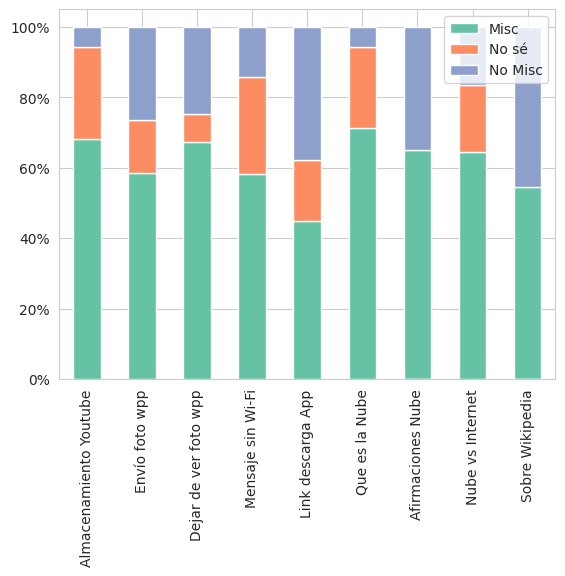

In [34]:
misc_tot    = analizar_misc_por_preg(total)
misc_tot['Total'] = misc_tot['Misc'] + misc_tot['No sé'] + misc_tot['No Misc']
print(misc_tot)

def dividir(fila):
       return fila.div(fila['Total'])
misc_tot = misc_tot.apply(dividir, axis=1)
misc_tot = misc_tot.drop(['Total'], axis=1)
# print(misc_tot)
# misc_tot.head
# misc_marmol = analizar_misc_por_preg(marmol)
# misc_manto  = analizar_misc_por_preg(mantovani)

# print("Promedio miscos por chique:", "{:.2f}".format(sum(misc_tot*range(len(misc_tot)))))
# print("Promedio miscos por chique Mantovani:", "{:.2f}".format(sum(misc_manto*range(len(misc_manto)))))
# print("Promedio miscos por chique Mármol:", "{:.2f}".format(sum(misc_marmol*range(len(misc_marmol)))))

# result = pd.concat([misc_tot, misc_marmol, misc_manto], axis=1)
# result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

# bar_width = 0.25

# br1 = np.arange(len(result))
# br2 = [x + bar_width for x in br1]
# br3 = [x + bar_width for x in br2]
misc_tot.plot(kind='bar', stacked=True)
# plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
# plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
# plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
# if include_title:
#        plt.title("Cantidad de Misconceptions totales\nPor escuela", fontsize=15)
# plt.xticks([x + bar_width for x in br1], result.index.astype(int))
# plt.xlabel("Cantidad de respuestas con misconception")
# plt.ylabel("Porcentaje de la muestra")
plt.legend()

plt.show()
# plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)